In [1]:
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.embeddings import HuggingFaceBgeEmbeddings

In [2]:
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

embeddings = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


C:\Users\rudra\AppData\Local\Temp\ipykernel_1604\1009423357.py:7: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
c:\Users\rudra\Projects\Gen AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

len(docs)

392

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [5]:

len(chunks)

973

In [6]:
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store

In [7]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})
# retriever.invoke("What is Kernelized Support Vector Machines?")

In [8]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [9]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [10]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [12]:
tool_node = ToolNode(tools)

In [13]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

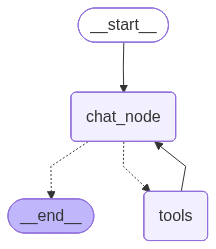

In [14]:
chatbot

In [15]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "What is Kernelized Support Vector Machines, summarize it briefly in a bullet points.."
                )
            )
        ]
    }
)

In [16]:

print(result['messages'][-1].content)

Kernelized Support Vector Machines (SVMs) are an extension of linear support vector machines that allow for more complex models. Here's a brief summary:

*   **Extension of Linear SVMs:** They build upon linear SVMs to handle non-linear relationships in data.
*   **Complex Models:** Unlike linear models that use hyperplanes, kernelized SVMs can create more intricate decision boundaries.
*   **Support Vectors:** During training, SVMs identify "support vectors," which are the data points crucial for defining the decision boundary between classes.
*   **Prediction:** To classify a new point, the SVM measures its distance to each support vector and makes a decision based on these distances.
*   **Strengths:** They are powerful, perform well on various datasets, and can handle both low and high-dimensional data.
*   **Weaknesses:** They don't scale well with a large number of samples (challenging for datasets over 100,000), require careful data preprocessing and parameter tuning, and can be